## This Notebook is organized into several sections: session startup, preprocess listings data, preprocess calendar data, and join and save the files. And at last do the EDA.

## Import functions and start session

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import col, when, lit, create_map
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
spark = SparkSession.builder \
  .appName("AirbnbPriceAnalysis-DataPreprocess") \
  .getOrCreate()

spark

25/12/18 20:08:03 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## Preprocess Data

### preprocess nyc-listings.csv: Limeng Jiang

In [3]:
# Load data
BUCKET = "gs://jyairbnb"

fname = "listings.csv.gz"
path = f"{BUCKET}/data_raw/{fname}"

df_listings = spark.read.csv(path, header=True, inferSchema=True)

Features were selected to represent listing capacity, location, property type, host reputation, and guest feedback. These are the core factors that theory and prior work suggest influence Airbnb pricing.

In [4]:
# Select & clean features
selected_cols = ['id', 'neighbourhood_group_cleansed', 'accommodates', 'bedrooms', 'beds',\
                 'bathrooms', 'bathrooms_text', 'property_type', 'room_type', 'amenities', 'host_is_superhost', \
                 'host_total_listings_count', 'instant_bookable', 'number_of_reviews', \
                 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_cleanliness', \
                 'review_scores_accuracy', 'review_scores_location']

In [5]:
df_listings = df_listings.select(selected_cols)

# take a look at the schema (especially dtypes)
df_listings.printSchema()

root
 |-- id: string (nullable = true)
 |-- neighbourhood_group_cleansed: string (nullable = true)
 |-- accommodates: string (nullable = true)
 |-- bedrooms: string (nullable = true)
 |-- beds: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- bathrooms_text: string (nullable = true)
 |-- property_type: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- amenities: string (nullable = true)
 |-- host_is_superhost: string (nullable = true)
 |-- host_total_listings_count: string (nullable = true)
 |-- instant_bookable: string (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- number_of_reviews_ltm: string (nullable = true)
 |-- review_scores_rating: string (nullable = true)
 |-- review_scores_cleanliness: string (nullable = true)
 |-- review_scores_accuracy: string (nullable = true)
 |-- review_scores_location: string (nullable = true)



**Clean:** <br>
Numerical columns: price, accommodates, bedrooms, beds, bathrooms, host_total_listings_count, number_of_reviews, number_of_reviews_ltm, review_scores_rating, review_scores_cleanliness, review_scores_accuracy, review_scores_location <br>

fill missing values in `bathrooms` from `bathrooms_text` column; assume that 1 shared bath counts for 0.5 bathroom. <br>
`accomodates`, `bedrooms`, and `beds`: can replace NA by mode. <br>
`amenities`: a list of texts. count(amenities) as a feature; do text analysis if time permits <br>
`host_total_listings_count`: can replace NA by median. <br>
`number_of_reviews`, `number_of_reviews_ltm`: replace NA with 0. <br>
`review_scores_`: replace NA with mean. <br>

Since the should-be-numerical columns are actually of dtype string, we need to replace these strings with NA before performing the NA replacement:

In [6]:
from itertools import chain

In [7]:
df_listings = df_listings.withColumn(
    "bathrooms_clean",
    F.when(
        F.col("bathrooms").rlike("^[0-9]+$"),
        F.col("bathrooms").cast("int")
    ).otherwise(None)
)

In [8]:
# fill missing values in `bathrooms` from `bathrooms_text` column
# assume that 1 shared bath counts for 0.5 bathroom, and so on
mapping = {'1 shared bath': 0.5, '1 bath': 1.0, '2 baths': 2.0, '2 shared baths': 1.0,\
           '1 private bath': 1.0, '1.5 shared baths': 0.75, '1.5 baths': 1.5, \
           '5.5 baths': 5.5,'2.5 baths':2.5, 'Half-bath':0.5,'3.5 baths':3.5,\
           '7 baths':7.0,'2 shared baths':1.0, '4 shared baths':2.0,'3 baths':3.0,\
           '3 shared baths':1.5,'4 baths':4.0, '0 baths':0.0, '0 shared baths':0.0,\
           'Private half-bath':0.5}
mapping_expr = F.create_map([F.lit(x) for x in chain(*mapping.items())])

df_listings = df_listings.withColumn(
    "bathrooms_clean",
    F.when(
        F.col("bathrooms_clean").isNull(),
        mapping_expr[F.col("bathrooms_text")]
    ).otherwise(F.col("bathrooms_clean"))
)

# if there are other missing values, replace with mode
mode_nyc = (df_listings
           .filter(F.col("bathrooms_clean").isNotNull())
           .groupBy("bathrooms_clean")
           .count()
           .orderBy(F.col("count").desc())
           .first()[0])
df_listings = df_listings.fillna({"bathrooms_clean": mode_nyc})
df_listings = df_listings.drop("bathrooms", "bathrooms_text")

In [9]:
df_listings = df_listings.withColumn(
    "beds_clean",
    F.when(
        F.col("beds").rlike("^[0-9]+$"),
        F.col("beds").cast("int")
    ).otherwise(None)
)

In [10]:
df_listings = df_listings.withColumn(
    "accommodates_clean",
    F.when(
        F.col("accommodates").rlike("^[0-9]+$"),
        F.col("accommodates").cast("int")
    ).otherwise(None)
)

In [11]:
df_listings = df_listings.withColumn(
    "bedrooms_clean",
    F.when(
        F.col("bedrooms").rlike("^[0-9]+$"),
        F.col("bedrooms").cast("int")
    ).otherwise(None)
)

In [12]:
# accomodates, bedrooms, and beds: can replace by mode
mode_acc = (df_listings
           .filter(F.col("accommodates_clean").isNotNull())
           .groupBy("accommodates_clean")
           .count()
           .orderBy(F.col("count").desc())
           .first()[0])
df_listings = df_listings.fillna({"accommodates_clean": mode_acc})
df_listings = df_listings.drop("accommodates")

mode_bed = (df_listings
           .filter(F.col("bedrooms_clean").isNotNull())
           .groupBy("bedrooms_clean")
           .count()
           .orderBy(F.col("count").desc())
           .first()[0])
df_listings = df_listings.fillna({"bedrooms_clean": mode_bed})
df_listings = df_listings.drop("bedrooms")

mode_bd = (df_listings
           .filter(F.col("beds_clean").isNotNull())
           .groupBy("beds_clean")
           .count()
           .orderBy(F.col("count").desc())
           .first()[0])
df_listings = df_listings.fillna({"beds_clean": mode_bd})
df_listings = df_listings.drop("beds")

In [13]:
# count amenities as a feature
df_listings = df_listings.withColumn('amenities_count', F.size(F.split(F.col('amenities'), ',')))
df_listings = df_listings.drop("amenities")

In [14]:
df_listings = df_listings.withColumn(
    "host_total_listings_count_clean",
    F.when(
        F.col("host_total_listings_count").rlike("^[0-9]+$"),
        F.col("host_total_listings_count").cast("int")
    ).otherwise(None)
)

In [15]:
# host_total_listings_count: replace by median
median_host_total = df_listings.approxQuantile(
    "host_total_listings_count_clean", [0.5], 0.01
)[0]

df_listings = df_listings.fillna({
    "host_total_listings_count_clean": median_host_total
})
df_listings = df_listings.drop("host_total_listings_count")

In [16]:
df_listings = df_listings.withColumn(
    "number_of_reviews_clean",
    F.when(
        F.col("number_of_reviews").rlike("^[0-9]+$"),
        F.col("number_of_reviews").cast("int")
    ).otherwise(None)
)

df_listings = df_listings.withColumn(
    "number_of_reviews_ltm_clean",
    F.when(
        F.col("number_of_reviews_ltm").rlike("^[0-9]+$"),
        F.col("number_of_reviews_ltm").cast("int")
    ).otherwise(None)
)

In [17]:
# number_of_reviews, number_of_reviews_ltm: replace with 0
df_listings = df_listings.fillna({"number_of_reviews_clean": 0, "number_of_reviews_ltm_clean": 0})
df_listings = df_listings.drop("number_of_reviews", "number_of_reviews_ltm")

In [18]:
df_listings = df_listings.withColumn(
    "review_scores_rating_clean",
    F.when(
        F.col("review_scores_rating").rlike("^[0-9]+$"),
        F.col("review_scores_rating").cast("int")
    ).otherwise(None)
)

df_listings = df_listings.withColumn(
    "review_scores_cleanliness_clean",
    F.when(
        F.col("review_scores_cleanliness").rlike("^[0-9]+$"),
        F.col("review_scores_cleanliness").cast("int")
    ).otherwise(None)
)

df_listings = df_listings.withColumn(
    "review_scores_accuracy_clean",
    F.when(
        F.col("review_scores_accuracy").rlike("^[0-9]+$"),
        F.col("review_scores_accuracy").cast("int")
    ).otherwise(None)
)

df_listings = df_listings.withColumn(
    "review_scores_location_clean",
    F.when(
        F.col("review_scores_location").rlike("^[0-9]+$"),
        F.col("review_scores_location").cast("int")
    ).otherwise(None)
)

In [19]:
# review_scores_: replace with mean
mean_rating = df_listings.agg(F.mean("review_scores_rating_clean")).collect()[0][0]
mean_clean = df_listings.agg(F.mean("review_scores_cleanliness_clean")).collect()[0][0]
mean_acc = df_listings.agg(F.mean("review_scores_accuracy_clean")).collect()[0][0]
mean_loc = df_listings.agg(F.mean("review_scores_location_clean")).collect()[0][0]

df_listings = df_listings.fillna({"review_scores_rating_clean": mean_rating,
                        "review_scores_cleanliness_clean": mean_clean,
                        "review_scores_accuracy_clean": mean_acc,
                        "review_scores_location_clean": mean_loc})
df_listings = df_listings.drop("review_scores_rating", "review_scores_cleanliness",
                     "review_scores_accuracy", "review_scores_location")

In [20]:
# check if these numerical columns are indeed numerical now
df_listings.dtypes

[('id', 'string'),
 ('neighbourhood_group_cleansed', 'string'),
 ('property_type', 'string'),
 ('room_type', 'string'),
 ('host_is_superhost', 'string'),
 ('instant_bookable', 'string'),
 ('bathrooms_clean', 'double'),
 ('beds_clean', 'int'),
 ('accommodates_clean', 'int'),
 ('bedrooms_clean', 'int'),
 ('amenities_count', 'int'),
 ('host_total_listings_count_clean', 'int'),
 ('number_of_reviews_clean', 'int'),
 ('number_of_reviews_ltm_clean', 'int'),
 ('review_scores_rating_clean', 'int'),
 ('review_scores_cleanliness_clean', 'int'),
 ('review_scores_accuracy_clean', 'int'),
 ('review_scores_location_clean', 'int')]

Categorical columns: neighbourhood_group_cleansed, property_type, room_type, host_is_superhost, instant_bookable <br>
create a new category called "missing" for missing values

In [24]:
from pyspark.ml import Pipeline

In [25]:
# convert categorical columns
categorical_cols = ['neighbourhood_group_cleansed', 'property_type', 'room_type',
                    'host_is_superhost', 'instant_bookable']

# keep na as a category
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

Do one-hot encoding on the categorical columns so that it satisfies the requirements for a GBT Regressor that will be trained later.

In [26]:
# One hot encoding for the categorical columns
encoders = [
    OneHotEncoder(inputCol=f"{col}_index", outputCol=f"{col}_vec")
    for col in categorical_cols
]

In [27]:
pipeline = Pipeline(stages=indexers + encoders)
df_listings = pipeline.fit(df_listings).transform(df_listings)
df_listings = df_listings.drop(*categorical_cols)

In [28]:
df_listings.printSchema()

root
 |-- id: string (nullable = true)
 |-- bathrooms_clean: double (nullable = false)
 |-- beds_clean: integer (nullable = false)
 |-- accommodates_clean: integer (nullable = false)
 |-- bedrooms_clean: integer (nullable = false)
 |-- amenities_count: integer (nullable = false)
 |-- host_total_listings_count_clean: integer (nullable = true)
 |-- number_of_reviews_clean: integer (nullable = false)
 |-- number_of_reviews_ltm_clean: integer (nullable = false)
 |-- review_scores_rating_clean: integer (nullable = true)
 |-- review_scores_cleanliness_clean: integer (nullable = true)
 |-- review_scores_accuracy_clean: integer (nullable = true)
 |-- review_scores_location_clean: integer (nullable = true)
 |-- neighbourhood_group_cleansed_index: double (nullable = false)
 |-- property_type_index: double (nullable = false)
 |-- room_type_index: double (nullable = false)
 |-- host_is_superhost_index: double (nullable = false)
 |-- instant_bookable_index: double (nullable = false)
 |-- neighbourh

In [29]:
output_path = "gs://jyairbnb/data_clean/listings_clean/"

df_listings.write.mode("overwrite").parquet(output_path)

print("Saved to:", output_path)

25/12/18 20:31:27 WARN DAGScheduler: Broadcasting large task binary with size 1275.5 KiB


Saved to: gs://jyairbnb/data_clean/listings_clean/


### preprocess nyc-calendar.csv: Jiawen Yin

A compressed file named `calendar.csv.gz` containing 12 months' worth of data was imported into the notebook all at once, so I created the variable **`paths`** to store the file paths for loading the complete calendar dataset.

In [34]:
paths = [
    f"gs://jyairbnb/data_raw/calendar.csv.gz"
] + [
    f"gs://jyairbnb/data_raw/calendar ({i}).csv.gz"
    for i in range(1, 12)
]

paths

['gs://jyairbnb/data_raw/calendar.csv.gz',
 'gs://jyairbnb/data_raw/calendar (1).csv.gz',
 'gs://jyairbnb/data_raw/calendar (2).csv.gz',
 'gs://jyairbnb/data_raw/calendar (3).csv.gz',
 'gs://jyairbnb/data_raw/calendar (4).csv.gz',
 'gs://jyairbnb/data_raw/calendar (5).csv.gz',
 'gs://jyairbnb/data_raw/calendar (6).csv.gz',
 'gs://jyairbnb/data_raw/calendar (7).csv.gz',
 'gs://jyairbnb/data_raw/calendar (8).csv.gz',
 'gs://jyairbnb/data_raw/calendar (9).csv.gz',
 'gs://jyairbnb/data_raw/calendar (10).csv.gz',
 'gs://jyairbnb/data_raw/calendar (11).csv.gz']

In [35]:
df_calendar = spark.read.option("header", True).csv(paths)

df_calendar.printSchema()    # Check column names and inferred data types
df_calendar.show(5)          # Preview sample rows

root
 |-- listing_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- available: string (nullable = true)
 |-- price: string (nullable = true)
 |-- adjusted_price: string (nullable = true)
 |-- minimum_nights: string (nullable = true)
 |-- maximum_nights: string (nullable = true)

+----------+----------+---------+-------+--------------+--------------+--------------+
|listing_id|      date|available|  price|adjusted_price|minimum_nights|maximum_nights|
+----------+----------+---------+-------+--------------+--------------+--------------+
|      2595|2025-01-03|        t|$225.00|          NULL|            30|          1125|
|      2595|2025-01-04|        t|$225.00|          NULL|            30|          1125|
|      2595|2025-01-05|        t|$225.00|          NULL|            30|          1125|
|      2595|2025-01-06|        t|$225.00|          NULL|            30|          1125|
|      2595|2025-01-07|        t|$225.00|          NULL|            30|          1125|
+---

I converted prices into numeric values, transformed availability into simple 0/1 flags, standardized key data types, and extracted year and week information from dates. Since the `adjusted_price` column was almost entirely NULL, I effectively dropped it by not selecting it when creating the new DataFrame, which overwrote the original `df_calendar`. Then I kept only the required columns and directly removed rows with missing values to ensure the dataset is clean and ready for further analysis.

In [37]:
import pyspark.sql.types as T

df_calendar = (
    df_calendar
    .withColumn(
        "price_clean",
        F.regexp_replace("price", "[$,]", "").cast(T.DoubleType())
    )   # Remove currency symbols and cast price to double
    .withColumn(
        "available_flag",
        F.when(F.col("available") == "t", 1).otherwise(0)
    )   # Encode availability as binary numeric flag
    .withColumn("listing_id", F.col("listing_id").cast(T.IntegerType()))
    .withColumn("date", F.to_date("date"))    # Convert date string to date type
    .withColumn("year", F.year("date"))       # Extract year from date for creating the "trend_yearly" feature in later steps
    .withColumn("week", F.weekofyear("date")) # Extract week number from date
)

# Keep only required columns and drop rows with missing values
df_calendar = df_calendar.select(
    "listing_id", "date", "year", "week",
    "price_clean", "available_flag"
).dropna()

# Check number of valid rows after cleaning 
print("Clean rows:", df_calendar.count())
df_calendar.show(5)

Clean rows: 53941215


+----------+----------+----+----+-----------+--------------+
|listing_id|      date|year|week|price_clean|available_flag|
+----------+----------+----+----+-----------+--------------+
|      2595|2025-01-03|2025|   1|      225.0|             1|
|      2595|2025-01-04|2025|   1|      225.0|             1|
|      2595|2025-01-05|2025|   1|      225.0|             1|
|      2595|2025-01-06|2025|   2|      225.0|             1|
|      2595|2025-01-07|2025|   2|      225.0|             1|
+----------+----------+----+----+-----------+--------------+
only showing top 5 rows



I aggregate daily calendar data to the weekly listing level to reduce daily noise and make pricing and availability patterns more stable and easier to analyze over time.

To capture booking behavior from different perspectives, both `available_rate` and `booked_ratio` were constructed during the feature engineering stage. Although these two metrics are mathematically complementary, they represent availability from the supply side and booking intensity from the demand side, respectively. For modeling purposes, only the variable that best aligns with each model’s objective was selected.

In [38]:
weekly = (
    df_calendar
    .groupBy("listing_id", "year", "week")                # Group data by listing_id and calendar week
    .agg(
        F.avg("price_clean").alias("avg_price"),          # Compute average weekly price
        F.sum("available_flag").alias("days_available"),  # Count available days in the week
        F.sum(F.when(F.col("available_flag") == 0, 1).otherwise(0)).alias("days_booked"),
        F.count("*").alias("total_days")
    )
    .withColumn("available_rate", F.col("days_available") / F.col("total_days"))  # Compute weekly availability rate
    .withColumn("booked_ratio",   F.col("days_booked")    / F.col("total_days"))  # Compute weekly booking ratio
)

In [39]:
print("Weekly rows:", weekly.count())
weekly.show(5)

+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
|listing_id|year|week|avg_price|days_available|days_booked|total_days|    available_rate|      booked_ratio|
+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
|     39282|2025|   7|    170.0|            14|         14|        28|               0.5|               0.5|
|    106363|2025|  24|     80.0|            14|         28|        42|0.3333333333333333|0.6666666666666666|
|     96471|2025|  13|    165.0|            35|          0|        35|               1.0|               0.0|
|    158176|2025|  43|    173.4|             0|         35|        35|               0.0|               1.0|
|    168123|2025|  17|    175.0|            42|          0|        42|               1.0|               0.0|
+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
only showing top 5 

### Feature Engineering of calendar.csv : Jiawen Yin

In [40]:
from pyspark.sql.window import Window

After weekly aggregation, the dataset was reassigned to `df_calendar` for consistent naming in later steps.

In [41]:
df_calendar = weekly

In [42]:
# Checking the rows these two dataframes
print("Listings rows:", df_listings.count())
print("Calendar rows:", df_calendar.count())

Listings rows: 55206


Calendar rows: 1737125


In [43]:
df_calendar.show(5)

+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
|listing_id|year|week|avg_price|days_available|days_booked|total_days|    available_rate|      booked_ratio|
+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
|     39282|2025|   7|    170.0|            14|         14|        28|               0.5|               0.5|
|    106363|2025|  24|     80.0|            14|         28|        42|0.3333333333333333|0.6666666666666666|
|     96471|2025|  13|    165.0|            35|          0|        35|               1.0|               0.0|
|    158176|2025|  43|    173.4|             0|         35|        35|               0.0|               1.0|
|    168123|2025|  17|    175.0|            42|          0|        42|               1.0|               0.0|
+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+
only showing top 5 

In [44]:
df_calendar.agg(F.max("total_days")).show()

+---------------+
|max(total_days)|
+---------------+
|             49|
+---------------+



InsideAirbnb does not provide a full year of calendar data. Each `calendar.csv` file is a snapshot covering only the next 30–60 days rather than an entire year.

Even when multiple calendar files from different months are downloaded, each file still represents a rolling window of upcoming availability from its own collection date. After merging all calendar files and removing duplicate dates, the number of unique days per listing typically remains around 40–60 days.

As a result, it is expected that the maximum value of `total_days` is 49 instead of 365. This does not indicate an error but reflects the structure of the InsideAirbnb dataset, which contains short-term future availability rather than full-year daily records.

In [45]:
# Just for checking.
df_calendar.agg(F.max("week")).show()

+---------+
|max(week)|
+---------+
|       52|
+---------+



In [46]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

In [47]:
df_calendar.printSchema()

root
 |-- listing_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- week: integer (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- days_available: long (nullable = true)
 |-- days_booked: long (nullable = true)
 |-- total_days: long (nullable = false)
 |-- available_rate: double (nullable = true)
 |-- booked_ratio: double (nullable = true)



### Create 4 new advanced features

I create additional time-based and demand-related features to capture seasonal effects, long-term time trends, and booking intensity, so that the dataset includes higher-level signals that are more informative for modeling than raw weekly metrics alone.

In [48]:
# Add quarters from week
df_calendar = df_calendar.withColumn(
    "quarter",
    F.when(F.col("week") <= 13, 1)
     .when(F.col("week") <= 26, 2)
     .when(F.col("week") <= 39, 3)
     .otherwise(4)
)

df_calendar = StringIndexer(inputCol="quarter", outputCol="quarter_index").fit(df_calendar).transform(df_calendar)
df_calendar = OneHotEncoder(inputCols=["quarter_index"], outputCols=["quarter_onehot"]).fit(df_calendar).transform(df_calendar)

df_calendar = df_calendar.drop("quarter", "quarter_index")

# Normalize to get trend_yearly
year_window = Window.partitionBy()

df_calendar = df_calendar.withColumn(
    "trend_yearly",
    (F.col("year") - F.min("year").over(year_window)) /
    (F.max("year").over(year_window) - F.min("year").over(year_window))
)

# Price per booked day 
df_calendar = df_calendar.withColumn(
    "price_per_booked_day",
    F.col("avg_price") / (F.col("days_booked") + F.lit(1))    # add 1 to avoid divide by 0
)

# Demand score calculating from price * booking ratio
df_calendar = df_calendar.withColumn(
    "demand_score",
    F.col("booked_ratio") * F.col("avg_price")
)



df_calendar.show(5)

25/12/18 21:45:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:45:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:45:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:47:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:47:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:47:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 2

+----------+----+----+---------+--------------+-----------+----------+-------------------+------------------+--------------+------------+--------------------+-----------------+
|listing_id|year|week|avg_price|days_available|days_booked|total_days|     available_rate|      booked_ratio|quarter_onehot|trend_yearly|price_per_booked_day|     demand_score|
+----------+----+----+---------+--------------+-----------+----------+-------------------+------------------+--------------+------------+--------------------+-----------------+
|     60611|2026|   5|   109.25|            12|         16|        28|0.42857142857142855|0.5714285714285714| (3,[0],[1.0])|         1.0|   6.426470588235294|62.42857142857142|
|     62925|2026|   3|    285.0|             0|         28|        28|                0.0|               1.0| (3,[0],[1.0])|         1.0|   9.827586206896552|            285.0|
|     75635|2025|  16|    120.0|            21|         21|        42|                0.5|               0.5| (3,[2

In [49]:
df_calendar.printSchema()

root
 |-- listing_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- week: integer (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- days_available: long (nullable = true)
 |-- days_booked: long (nullable = true)
 |-- total_days: long (nullable = false)
 |-- available_rate: double (nullable = true)
 |-- booked_ratio: double (nullable = true)
 |-- quarter_onehot: vector (nullable = true)
 |-- trend_yearly: double (nullable = true)
 |-- price_per_booked_day: double (nullable = true)
 |-- demand_score: double (nullable = true)



### Join 2 cleaned data files

We use an inner join so the final dataset contains listings that have both listing-level attributes and calendar-level weekly signals. This guarantees that every row used for training has complete information.

In [50]:
# We rename id to listing_id to match the calendar dataset
df_listings = df_listings.withColumnRenamed("id", "listing_id")

df = df_calendar.join(
    df_listings,
    on="listing_id",
    how="inner"
)

df.show(5)

25/12/18 21:48:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:48:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:48:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/12/18 21:49:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:49:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:49:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance

+----------+----+----+---------+--------------+-----------+----------+------------------+------------------+--------------+------------+--------------------+------------------+---------------+----------+------------------+--------------+---------------+-------------------------------+-----------------------+---------------------------+--------------------------+-------------------------------+----------------------------+----------------------------+----------------------------------+-------------------+---------------+-----------------------+----------------------+--------------------------------+-----------------+---------------+---------------------+--------------------+
|listing_id|year|week|avg_price|days_available|days_booked|total_days|    available_rate|      booked_ratio|quarter_onehot|trend_yearly|price_per_booked_day|      demand_score|bathrooms_clean|beds_clean|accommodates_clean|bedrooms_clean|amenities_count|host_total_listings_count_clean|number_of_reviews_clean|number_o

In [51]:
df.write.mode("overwrite").parquet("gs://jyairbnb/data_clean/joined_Q1/")

25/12/18 21:51:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:51:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:51:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:51:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:53:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 21:53:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/18 2

### EDA : Jiawen Yin

In [18]:
# Check all of the features are numeric.
df.printSchema()

root
 |-- listing_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- week: integer (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- days_available: long (nullable = true)
 |-- days_booked: long (nullable = true)
 |-- total_days: long (nullable = true)
 |-- available_rate: double (nullable = true)
 |-- booked_ratio: double (nullable = true)
 |-- trend_yearly: double (nullable = true)
 |-- price_per_booked_day: double (nullable = true)
 |-- demand_score: double (nullable = true)
 |-- bathrooms_clean: double (nullable = true)
 |-- beds_clean: integer (nullable = true)
 |-- accommodates_clean: integer (nullable = true)
 |-- bedrooms_clean: integer (nullable = true)
 |-- amenities_count: integer (nullable = true)
 |-- host_total_listings_count_clean: integer (nullable = true)
 |-- number_of_reviews_clean: integer (nullable = true)
 |-- number_of_reviews_ltm_clean: integer (nullable = true)
 |-- review_scores_rating_clean: integer (nullable = true)
 |-- re

In [19]:
# Check the size of the joined dataframe.
print("Number of rows:", df.count())
print("")
print("Number of columns:", len(df.columns))

Number of rows: 1528864

Number of columns: 34


We choose these 7 kinds of features to do the EDA.

**1. Time and Trend:** "year", "week", "trend_yearly"

**2. Pricing and Demand:** "avg_price", "price_per_booked_day", "demand_score"

**3. Supply and Availability:** "days_available", "days_booked", "total_days", "available_rate"

**4. Property Size and Capacity:** "bathrooms_clean", "beds_clean", "bedrooms_clean", "accommodates_clean", "amenities_count"

**5. Reviews and Guest Feedback:** "number_of_reviews_clean", "number_of_reviews_ltm_clean", "review_scores_rating_clean", "review_scores_cleanliness_clean", "review_scores_accuracy_clean", "review_scores_location_clean"

**6. Host and Booking Characteristics:** "host_total_listings_count_clean", "host_is_superhost_index", "instant_bookable_index"

**7. Location and Property Type:** "neighbourhood_group_cleansed_index", "property_type_index", "room_type_index"

In [20]:
eda_cols = [
    "year", "week", "trend_yearly",
    "avg_price", "price_per_booked_day", "demand_score", 
    "days_available", "days_booked", "total_days", "available_rate", 
    "bathrooms_clean", "beds_clean", "bedrooms_clean", "accommodates_clean", "amenities_count",
    "number_of_reviews_clean", "number_of_reviews_ltm_clean",
    "review_scores_rating_clean", "review_scores_cleanliness_clean",
    "review_scores_accuracy_clean", "review_scores_location_clean",
    "host_total_listings_count_clean", "host_is_superhost_index", "instant_bookable_index",
    "neighbourhood_group_cleansed_index", "property_type_index", "room_type_index"
]

df.select(eda_cols).describe().show()

25/12/16 00:13:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:13:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:13:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:13:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:13:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:13:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------+------------------+------------------+------------------+------------------+--------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-----------------------+---------------------------+--------------------------+-------------------------------+----------------------------+----------------------------+-------------------------------+-----------------------+----------------------+----------------------------------+-------------------+------------------+
|summary|              year|              week|      trend_yearly|         avg_price|price_per_booked_day|      demand_score|    days_available|       days_booked|        total_days|    available_rate|    bathrooms_clean|        beds_clean|    bedrooms_clean|accommodates_clean|   amenities_count|number_of_reviews_clean|number_of_reviews_ltm_clean|review_scores_rating_clean|revi

Since the entire dataframe has numerous columns, making it inconvenient to view the summary results, I will now break it down into several smaller sections to present the summary in detail.

In [24]:
core_cols = [
    "avg_price",
    "available_rate",
    "demand_score",
    "review_scores_rating_clean"
]

df.select(core_cols).describe().show()

+-------+------------------+-------------------+------------------+--------------------------+
|summary|         avg_price|     available_rate|      demand_score|review_scores_rating_clean|
+-------+------------------+-------------------+------------------+--------------------------+
|  count|           1528864|            1528864|           1528864|                   1528864|
|   mean|188.07210153309302|0.27718895815035594|122.76221723860226|         132.7716677219164|
| stddev| 705.2234942760491| 0.4147698415010656| 613.1105699661931|         187.9216275150934|
|    min|               0.0|                0.0|               0.0|                         0|
|    max|          100000.0|                1.0|          100000.0|                      1125|
+-------+------------------+-------------------+------------------+--------------------------+



- The dataset has more than 1.5 million weekly records.
- Average price varies a lot and has some very large values.
- The availability rate is between 0 and 1 and the average is low, which suggests many listings are often booked.
- The demand score follows the price pattern because it is based on price and booking activity.
- Review scores are generally high but still show variation across listings.

I plot the price distribution after removing extreme outliers so it is easier to see the overall pattern.

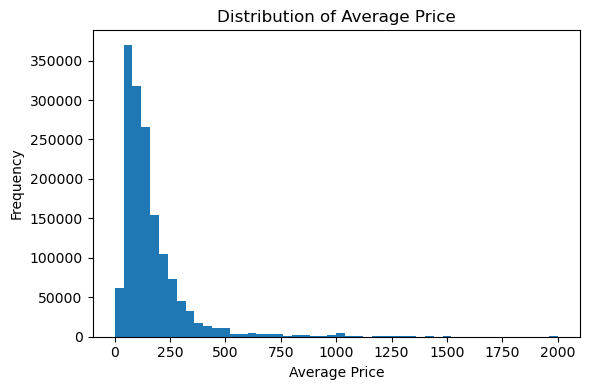

In [28]:
import matplotlib.pyplot as plt

pdf = (df
    .select("avg_price")
    .where(df.avg_price <= 2000)  # We consider prices averaging above $2,000 to be outliers.
    .toPandas()
)

plt.figure(figsize=(6,4))
plt.hist(pdf["avg_price"], bins=50)
plt.title("Distribution of Average Price")
plt.xlabel("Average Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

- The distribution of average price is strongly right-skewed.
- Most listings have relatively low average prices.
- A small number of listings have very high prices, which creates a long right tail.

I include the week variable to capture weekly seasonality.

In [23]:
df.select("week", "trend_yearly").describe().show()

25/12/16 00:23:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:23:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:23:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:23:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:23:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/12/16 00:23:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------+------------------+------------------+
|summary|              week|      trend_yearly|
+-------+------------------+------------------+
|  count|           1528864|           1528864|
|   mean|24.530794105950562|0.5574658700839316|
| stddev| 16.53970979599455|0.2856974583732044|
|    min|                 1|               0.0|
|    max|                52|               1.0|
+-------+------------------+------------------+



- The mean value of `week` is around the middle of the year, which suggests weeks are fairly evenly distributed.  
- The `yearly_trend` variable is scaled between 0 and 1 and captures long-term time progression.  
- This confirms that both short-term weekly patterns and long-term trends are properly represented.

Explores the basic size and capacity characteristics of listings.

In [26]:
df.select(
    "bathrooms_clean",
    "beds_clean",
    "bedrooms_clean",
    "accommodates_clean",
    "amenities_count"
).describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+
|summary|   bathrooms_clean|        beds_clean|    bedrooms_clean|accommodates_clean|   amenities_count|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|           1528864|           1528864|           1528864|           1528864|           1528864|
|   mean| 1.000894127927664|1.2278142463947088|1.2026020627079976| 2.493999466270381|0.5875303493312681|
| stddev|0.4286508450607104|0.8282685286989324| 0.684603649507743|1.5054219500132737|0.8093939406937262|
|    min|               0.0|                 0|                 0|                 1|                -1|
|    max|              13.0|                40|                14|                16|                 2|
+-------+------------------+------------------+------------------+------------------+------------------+



- The average number of bathrooms is around 1.  
- Most listings have 1–2 beds and about 1 bedroom.  
- On average, listings accommodate around 2 to 3 guests.  
- The number of amenities is relatively limited for most listings.